# Unit 5: BCI 范式实战

## 学习目标

- 实现完整的运动想象 (MI) BCI 管线：CSP 特征 → LDA/SVM 分类 → 准确率评估
- 理解 SSVEP BCI 的 CCA (典型相关分析) 频率检测方法
- 掌握交叉验证评估策略（留一法、k-fold）
- 实现实时分类反馈环路的模拟
- 理解 ITR (信息传输率) 等 BCI 性能指标

---

## 5.1 运动想象 (Motor Imagery) BCI

运动想象 BCI 是最经典的主动式 BCI 范式。当被试想象左手或右手运动时，
对侧感觉运动皮层在 μ (8-12 Hz) 和 β (18-26 Hz) 频段出现 ERD。

### 标准 MI-BCI 管线

```text
EEG Data → Bandpass (8-30Hz) → CSP Spatial Filter → Log-Variance Feature
         → LDA/SVM Classifier → Prediction (Left/Right)
```

### 关键电极位点

- **C3** (CH3): 右侧肢体运动想象时出现 ERD
- **C4** (CH4): 左侧肢体运动想象时出现 ERD
- **Cz**: 下肢/足部运动想象

### 分类器选择

| 分类器 | 优点 | 缺点 | MI-BCI 表现 |
|--------|------|------|-------------|
| **LDA** | 简单、快速、可解释 | 线性边界 | 基准方法 |
| **SVM (RBF)** | 非线性、泛化好 | 需要调参 | 通常优于 LDA |
| **Riemannian** | 直接操作协方差矩阵 | 计算量大 | SOTA 方法 |

In [2]:
# ============================================================
# 代码 5.1: 完整 MI-BCI 管线 (CSP + LDA + 交叉验证)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.linalg import eigh
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
# seaborn 是 Python 里的一个统计可视化库，主要用来画更好看的统计图。

rng = np.random.default_rng(42)
SFREQ = 250.0

# ---- 1. 生成模拟 MI 数据 ----
def generate_mi_dataset(n_trials_per_class=50, n_channels=8, trial_duration=2.0,
                        sfreq=250.0, seed=42):
    """
    生成更真实的运动想象 EEG 数据集。
    
    关键设计:
    - Left MI: C3 (index 2) alpha/beta ERD 更强
    - Right MI: C4 (index 3) alpha/beta ERD 更强
    - 包含试次间变异和噪声
    """
    rng = np.random.default_rng(seed)
    n_samples = int(trial_duration * sfreq)
    t = np.arange(n_samples) / sfreq # 时间轴
    
    def make_trials(active_ch):
        trials = np.zeros((n_trials_per_class, n_channels, n_samples))
        # 生成每个试次的 EEG 信号
        for tr in range(n_trials_per_class):
            # 生成每个通道的 EEG 信号
            for ch in range(n_channels):
                # 空间衰减：离激活通道越远 alpha/beta 越强（模拟正常活动）
                dist = abs(ch - active_ch)
                alpha_amp = 25 * np.exp(-dist / 1.5) + 5  # 基线 + ERD 区
                beta_amp = 10 * np.exp(-dist / 2.0) + 3
                
                noise_amp = rng.uniform(3, 8)
                noise = rng.normal(0, noise_amp, n_samples) # shape: (n_samples,)
                
                # 生成 alpha 节律信号（10Hz 左右，带随机频率偏移和相位偏移）
                # 2 * np.pi * f * t 是角频率公式，rng.uniform(-0.5, 0.5) 添加频率随机性
                # rng.uniform(0, 2*np.pi) 添加随机初始相位，使各试次信号不同步
                alpha = alpha_amp * np.sin(2 * np.pi * (10 + rng.uniform(-0.5, 0.5)) * t
                                            + rng.uniform(0, 2*np.pi))
                beta = beta_amp * np.sin(2 * np.pi * (22 + rng.uniform(-1, 1)) * t
                                          + rng.uniform(0, 2*np.pi))
                
                trials[tr, ch] = alpha + beta + noise
        return trials
    
    X_left = make_trials(active_ch=2)   # C3 shape: (n_trials_per_class, n_channels, n_samples)
    X_right = make_trials(active_ch=3)  # C4 shape: (n_trials_per_class, n_channels, n_samples)
    
    y_left = np.zeros(n_trials_per_class)      # Label 0 shape: (n_trials_per_class,)
    y_right = np.ones(n_trials_per_class)       # Label 1 shape: (n_trials_per_class,)
    
    X = np.vstack([X_left, X_right])  # shape: (2*n_trials_per_class, n_channels, n_samples)
    y = np.hstack([y_left, y_right])  # shape: (2*n_trials_per_class,)
    
    return X, y


# 生成数据
X_all, y_all = generate_mi_dataset(n_trials_per_class=80, n_channels=8,
                                    trial_duration=2.0, sfreq=SFREQ, seed=42)

print(f"Dataset: {X_all.shape[0]} trials × {X_all.shape[1]} channels × {X_all.shape[2]} samples")
print(f"Class distribution: Left MI={np.sum(y_all==0)}, Right MI={np.sum(y_all==1)}")


Dataset: 160 trials × 8 channels × 500 samples
Class distribution: Left MI=80, Right MI=80


In [3]:

# ---- 2. 应用带通滤波器 (8-30 Hz) ----
b_bp, a_bp = signal.butter(4, [8/(SFREQ/2), 30/(SFREQ/2)], btype="band")
# 可以直接对X_all滤波，因为filtfilt支持多维数组，axis=-1表示沿时间轴滤波
X_filtered = signal.filtfilt(b_bp, a_bp, X_all, axis=-1)

# ---- 3. CSP 特征提取 ----
class CSP:
    def __init__(self, n_components=4):
        self.n_components = n_components
        self.filters = None
    
    def fit(self, X, y):
        n_channels = X.shape[1]
        X1 = X[y == 0]
        X2 = X[y == 1]
        cov1 = np.mean([np.cov(t) for t in X1], axis=0)
        cov2 = np.mean([np.cov(t) for t in X2], axis=0)
        cov1 += 1e-6 * np.eye(n_channels)
        cov2 += 1e-6 * np.eye(n_channels)
        eigvals, eigvecs = eigh(cov1, cov1 + cov2)
        idx = np.argsort(eigvals)[::-1]
        eigvecs = eigvecs[:, idx]
        half = self.n_components // 2
        self.filters = np.hstack([eigvecs[:, :half], eigvecs[:, -half:]]).T
        return self
    
    def transform(self, X):
        features = []
        for trial in X:
            filtered = self.filters @ trial
            features.append(np.log(np.var(filtered, axis=1) + 1e-10))
        return np.array(features)


# ---- 4. 交叉验证评估 ----
# 使用分层10折交叉验证(训练集9折，测试集1折)，确保每折中类别比例与原始数据一致
# shuffle=True 表示在划分前打乱数据，random_state=42 保证结果可复现
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
lda_scores = []
svm_scores = []
all_predictions_lda = []
all_true_labels = []

# 使用分层10折交叉验证对过滤后的EEG数据进行训练和测试集划分
# cv.split()返回每一折的训练集和测试集索引
# enumerate用于获取当前折数(fold)，便于后续可能的调试或日志记录
# 分层抽样确保每一折中左右手运动想象样本的比例与原始数据一致(通过y_all作为类别标签)
for fold, (train_idx, test_idx) in enumerate(cv.split(X_filtered, y_all)):
    X_train, X_test = X_filtered[train_idx], X_filtered[test_idx] # X_train:(90% trials, n_channels, n_samples) X_test:(10% trials, n_channels, n_samples)
    y_train, y_test = y_all[train_idx], y_all[test_idx] # y_train:(90% trials,) y_test:(10% trials,)
    
    # CSP
    csp = CSP(n_components=4)
    csp.fit(X_train, y_train)
    feat_train = csp.transform(X_train)
    feat_test = csp.transform(X_test)
    
    # LDA
    lda = LDA()
    lda.fit(feat_train, y_train)
    lda_score = lda.score(feat_test, y_test)
    lda_scores.append(lda_score)
    
    # SVM
    svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
    svm.fit(feat_train, y_train)
    svm_score = svm.score(feat_test, y_test)
    svm_scores.append(svm_score)
    
    all_predictions_lda.extend(lda.predict(feat_test))
    all_true_labels.extend(y_test)

print(f"\n{'='*60}")
print(f"MI-BCI Classification Results (10-fold CV)")
print(f"{'='*60}")
print(f"LDA Accuracy: {np.mean(lda_scores)*100:.1f}% +/- {np.std(lda_scores)*100:.1f}%")
print(f"SVM Accuracy: {np.mean(svm_scores)*100:.1f}% +/- {np.std(svm_scores)*100:.1f}%")



MI-BCI Classification Results (10-fold CV)
LDA Accuracy: 100.0% +/- 0.0%
SVM Accuracy: 100.0% +/- 0.0%


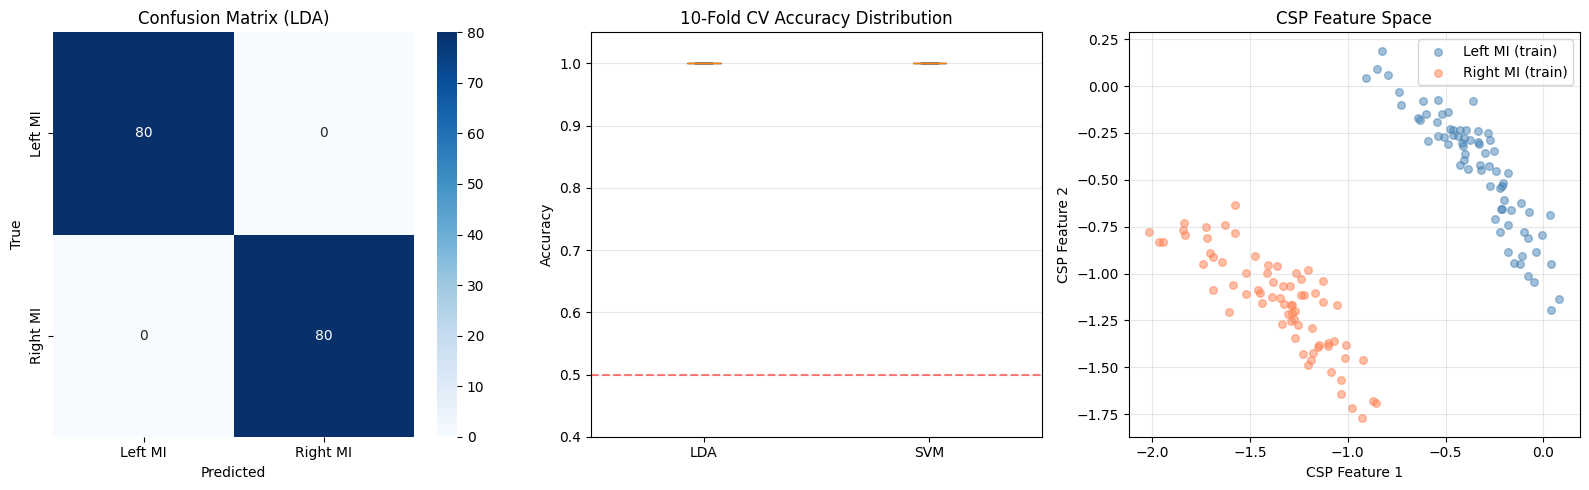

In [5]:

# ---- 5. 可视化 ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 混淆矩阵
cm = confusion_matrix(all_true_labels, all_predictions_lda)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Left MI", "Right MI"],
            yticklabels=["Left MI", "Right MI"])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix (LDA)")

# 交叉验证箱线图
axes[1].boxplot([lda_scores, svm_scores], tick_labels=["LDA", "SVM"],
                patch_artist=True)
axes[1].set_ylabel("Accuracy")
axes[1].set_title("10-Fold CV Accuracy Distribution")
axes[1].set_ylim(0.4, 1.05)
axes[1].axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Chance")
axes[1].grid(True, alpha=0.3, axis="y")

# CSP 特征空间 (最后一个 fold)
axes[2].scatter(feat_train[y_train==0, 0], feat_train[y_train==0, 1],
                c="steelblue", alpha=0.5, s=30, label="Left MI (train)")
axes[2].scatter(feat_train[y_train==1, 0], feat_train[y_train==1, 1],
                c="coral", alpha=0.5, s=30, label="Right MI (train)")
axes[2].set_xlabel("CSP Feature 1")
axes[2].set_ylabel("CSP Feature 2")
axes[2].set_title("CSP Feature Space")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5.2 SSVEP BCI

Steady-State Visual Evoked Potential  
稳态视觉诱发电位 (SSVEP) 是被试注视特定频率闪烁刺激时，枕叶 EEG 出现与刺激频率相同的振荡响应。

### CCA (Canonical Correlation Analysis) 频率检测

CCA 寻找多通道 EEG 信号与参考正弦/余弦模板之间的最大相关性：

$$\rho_f = \max_{w_x, w_y} \text{corr}(w_x^T X,\; w_y^T Y_f)$$

其中 $Y_f$ 是频率 $f$ 的正弦/余弦参考信号：

$$Y_f = \begin{bmatrix} \sin(2\pi f t) \\ \cos(2\pi f t) \\ \sin(4\pi f t) \\ \cos(4\pi f t) \\ \vdots \end{bmatrix}$$

选择使 $\rho_f$ 最大的 $f$ 作为检测到的刺激频率。

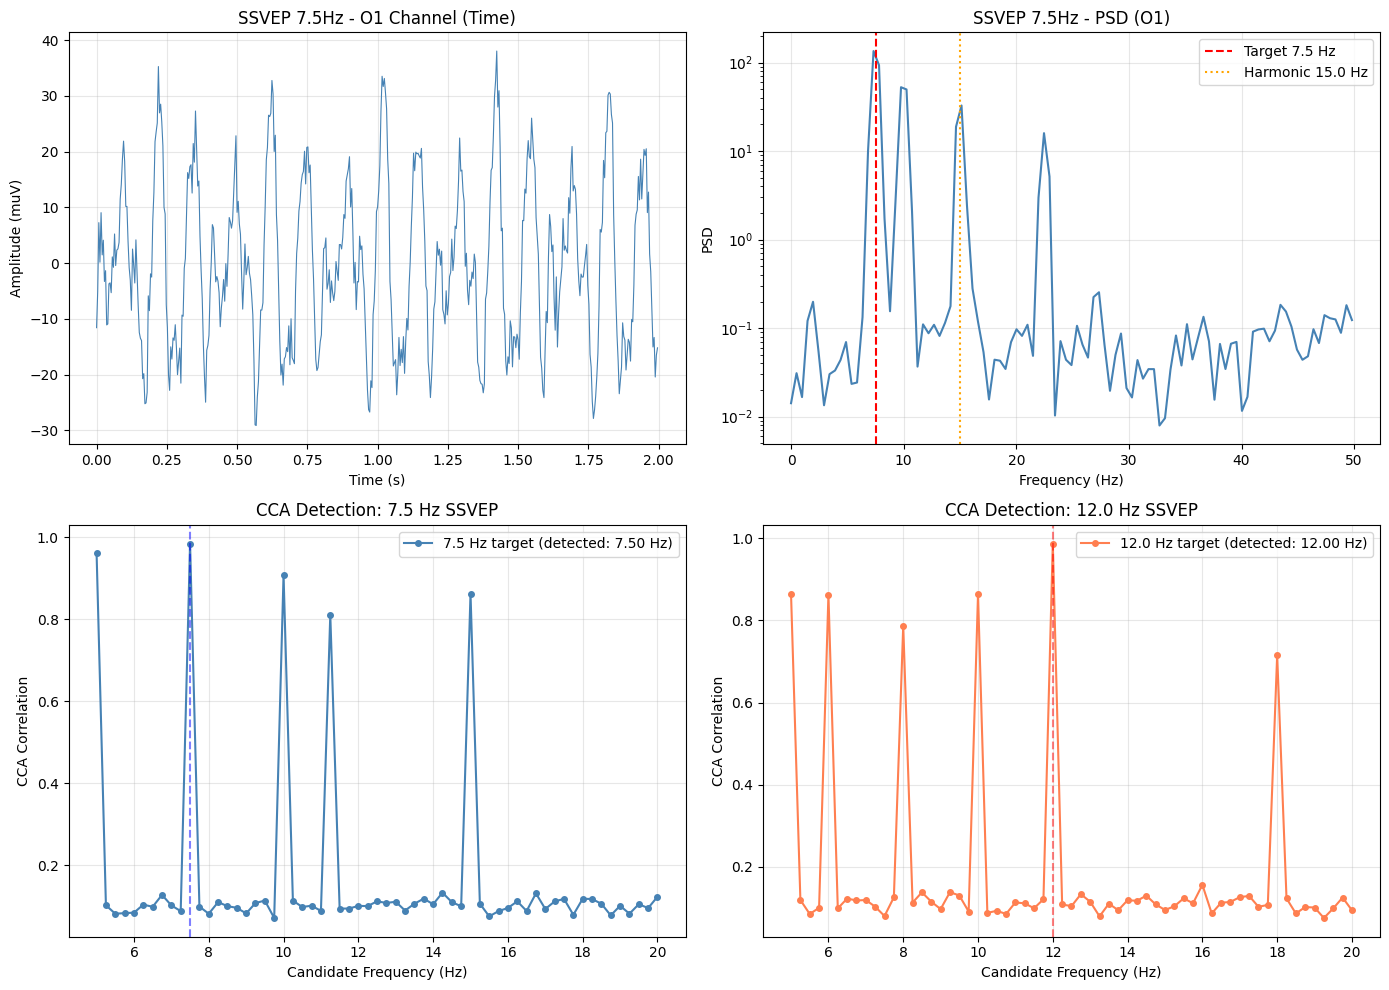

SSVEP CCA Detection Results:
  Target:  7.5 Hz → Detected: 7.50 Hz (rho_max=0.9845)
  Target: 12.0 Hz → Detected: 12.00 Hz (rho_max=0.9872)


In [7]:
# ============================================================
# 代码 5.2: SSVEP CCA 频率检测
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.cross_decomposition import CCA

SFREQ = 250.0

# ---- 生成模拟 SSVEP 数据 ----
def generate_ssvep_data(target_freq, n_channels=8, duration=4.0, sfreq=250.0,
                       noise_level=3.0, harmonics=3, seed=42):
    """
    生成 SSVEP trial 数据。
    
    Parameters
    ----------
    target_freq : float
        刺激闪烁频率 (Hz)
    harmonics : int
        包含的谐波数量
    
    Returns
    -------
    data : ndarray (n_channels, n_samples)
        生成的 SSVEP 数据
    t : ndarray
        时间轴 (秒)
    """
    rng = np.random.default_rng(seed)
    n_samples = int(duration * sfreq) # 采样点数
    t = np.arange(n_samples) / sfreq # 时间轴
    
    data = np.zeros((n_channels, n_samples))
    for ch in range(n_channels):
        # 后部通道 (O1/O2/Oz) SSVEP 更强
        # 枕部权重：O1/O2/Oz 权重为1.0，其他通道权重为0.3
        occipital_weight = 1.0 if ch >= 5 else 0.3
        
        # 基频 + 谐波
        signal_comp = 0
        for h in range(1, harmonics + 1):
            amp = 15 * occipital_weight / h  # 谐波幅度递减
            signal_comp += amp * np.sin(2 * np.pi * target_freq * h * t
                                         + rng.uniform(0, 2*np.pi))
        
        noise = rng.normal(0, noise_level, n_samples)
        # 添加 1/f 背景
        # 给模拟 EEG 数据额外加一个 10 Hz 的背景脑电节律，可以理解成模拟真实 EEG 里的 alpha 节律背景噪声
        background = 20 * np.sin(2 * np.pi * 10 * t) * occipital_weight * 0.5
        
        data[ch] = signal_comp + background + noise
    
    return data, t


def cca_ssvep_detect(eeg_data, candidate_freqs, sfreq=250.0, n_harmonics=3):
    """
    使用 CCA 检测 SSVEP 频率。
    
    Parameters
    ----------
    eeg_data : ndarray (n_channels, n_samples)
    candidate_freqs : list of float
        候选刺激频率列表
    sfreq : float, optional
        采样率 (Hz)
        default: 250.0
    n_harmonics : int, optional
        使用的谐波数量
        default: 3
        
    Returns
    -------
    best_freq : float
        检测到的频率
    rho_values : list of float
        各候选频率的相关系数
    """
    n_samples = eeg_data.shape[1] # 采样点数
    t = np.arange(n_samples) / sfreq # 时间轴
    
    rho_values = []
    for freq in candidate_freqs:
        # 构建参考信号 Y_f
        ref = []
        # sin(2πft), cos(2πft)
        # sin(2π2ft), cos(2π2ft)
        # sin(2π3ft), cos(2π3ft)
        # h谐波阶数，表示第几个谐波
        for h in range(1, n_harmonics + 1):
            ref.append(np.sin(2 * np.pi * freq * h * t))
            ref.append(np.cos(2 * np.pi * freq * h * t))
        Y = np.array(ref).T  # (n_samples, 2*n_harmonics)
        
        # CCA
        cca = CCA(n_components=1, scale=False, max_iter=500)
        try:
            X_c, Y_c = cca.fit_transform(eeg_data.T, Y)
            rho = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]
            rho_values.append(rho)
        except Exception:
            rho_values.append(0.0)
    
    best_idx = np.argmax(rho_values)
    return candidate_freqs[best_idx], rho_values


# ---- 生成两种刺激频率的 SSVEP 数据 ----
FREQ_7 = 7.5   # Hz
FREQ_12 = 12.0  # Hz

# 生成 7.5 Hz 12.0 Hz SSVEP 数据(稳态视觉诱发电位)
ssvep_7hz, t_ssvep = generate_ssvep_data(FREQ_7, duration=4.0, sfreq=SFREQ, seed=10)
ssvep_12hz, _ = generate_ssvep_data(FREQ_12, duration=4.0, sfreq=SFREQ, seed=20)

# CCA 检测
# 从 5 Hz 到 20 Hz，均匀取 61 个点作为候选频率
# 每隔 0.25 Hz 取一个候选频率
candidate_freqs = np.linspace(5, 20, 61)  # 候选频率 5-20 Hz

# ρ 越接近 1，说明越相关
# ρ 越接近 0，说明几乎不相关
# ρ 越接近 -1，说明强负相关
detected_7, rho_7 = cca_ssvep_detect(ssvep_7hz, candidate_freqs, SFREQ)
detected_12, rho_12 = cca_ssvep_detect(ssvep_12hz, candidate_freqs, SFREQ)

# ---- 可视化 ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 7.5 Hz SSVEP: 时域 (O1 通道)
axes[0, 0].plot(t_ssvep[:500], ssvep_7hz[6, :500], color="steelblue", linewidth=0.8)
axes[0, 0].set_title(f"SSVEP 7.5Hz - O1 Channel (Time)")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Amplitude (muV)")
axes[0, 0].grid(True, alpha=0.3)

# 7.5 Hz SSVEP: PSD 功率谱密度曲线(O1 通道)
f, psd = signal.welch(ssvep_7hz[6], fs=SFREQ, nperseg=512)
axes[0, 1].semilogy(f[f < 50], psd[f < 50], color="steelblue")
axes[0, 1].axvline(FREQ_7, color="red", linestyle="--", label=f"Target {FREQ_7} Hz")
axes[0, 1].axvline(FREQ_7*2, color="orange", linestyle=":", label=f"Harmonic {FREQ_7*2} Hz")
axes[0, 1].set_title(f"SSVEP 7.5Hz - PSD (O1)")
axes[0, 1].set_xlabel("Frequency (Hz)")
axes[0, 1].set_ylabel("PSD")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# CCA 7.5 Hz 相关系数曲线
axes[1, 0].plot(candidate_freqs, rho_7, "o-", color="steelblue",
                label=f"7.5 Hz target (detected: {detected_7:.2f} Hz)", markersize=4)
axes[1, 0].axvline(FREQ_7, color="blue", linestyle="--", alpha=0.5)
axes[1, 0].set_xlabel("Candidate Frequency (Hz)")
axes[1, 0].set_ylabel("CCA Correlation")
axes[1, 0].set_title("CCA Detection: 7.5 Hz SSVEP")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# CCA 12.0 Hz 相关系数曲线
axes[1, 1].plot(candidate_freqs, rho_12, "o-", color="coral",
                label=f"12.0 Hz target (detected: {detected_12:.2f} Hz)", markersize=4)
axes[1, 1].axvline(FREQ_12, color="red", linestyle="--", alpha=0.5)
axes[1, 1].set_xlabel("Candidate Frequency (Hz)")
axes[1, 1].set_ylabel("CCA Correlation")
axes[1, 1].set_title("CCA Detection: 12.0 Hz SSVEP")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"SSVEP CCA Detection Results:")
print(f"  Target:  7.5 Hz → Detected: {detected_7:.2f} Hz (rho_max={max(rho_7):.4f})")
print(f"  Target: 12.0 Hz → Detected: {detected_12:.2f} Hz (rho_max={max(rho_12):.4f})")

## 5.3 BCI 性能指标

### 准确率 (Accuracy)

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

### 信息传输率 (ITR)

ITR 是 BCI 的综合性能指标，结合准确率、类别数和单次命令时间：

$$\text{ITR} = \frac{60}{T} \left[ \log_2 N + P \log_2 P + (1-P) \log_2 \frac{1-P}{N-1} \right] \; \text{bits/min}$$

其中 $P$ 为准确率，$N$ 为类别数，$T$ 为单次命令时间（秒）。

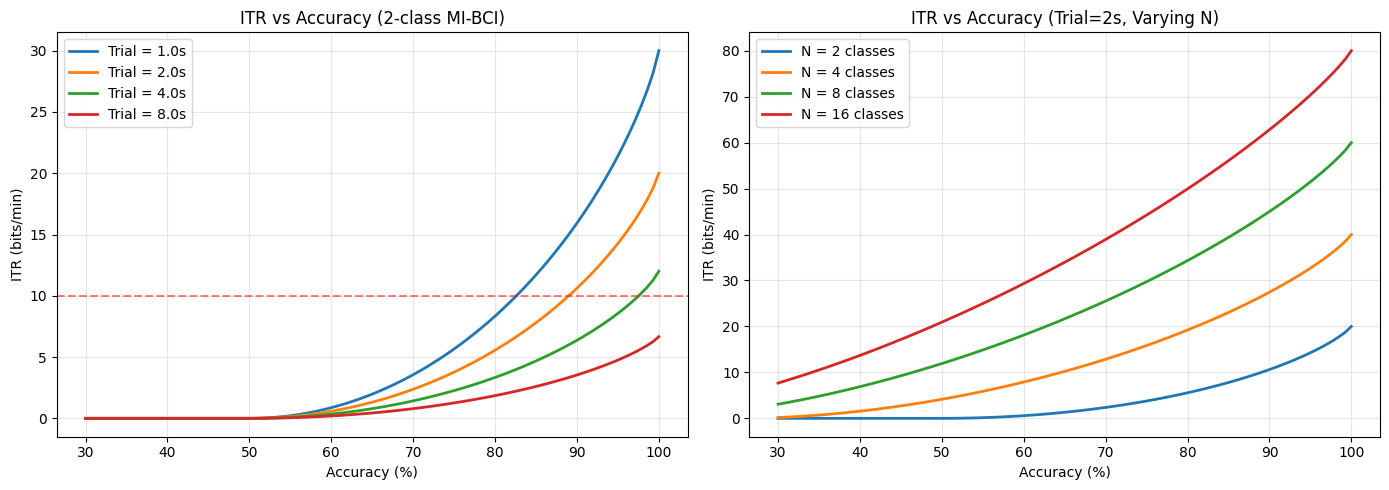


MI-BCI ITR Calculation:
  LDA: Acc=100.0%, ITR=20.00 bits/min
  SVM: Acc=100.0%, ITR=20.00 bits/min


In [8]:
# ============================================================
# 代码 5.3: BCI 性能指标计算（ITR）
# ============================================================
import numpy as np
import matplotlib.pyplot as plt


def compute_itr(accuracy, n_classes, trial_duration, inter_trial_interval=1.0):
    """
    计算信息传输率 (ITR)。
    
    Parameters
    ----------
    accuracy : float
        分类准确率 (0-1)
    n_classes : int
        类别数
    trial_duration : float
        单次 trial 时长（秒）
    inter_trial_interval : float
        Trial 间间隔（秒）
        
    Returns
    -------
    itr : float
        信息传输率 (bits/min)
    """
    T = trial_duration + inter_trial_interval  # 总命令时间
    P = accuracy
    N = n_classes
    
    if P == 1.0:
        itr = (60 / T) * np.log2(N)
    elif P < 1/N:
        itr = 0.0  # 低于随机水平
    else:
        term = (np.log2(N) + P * np.log2(P) +
                (1 - P) * np.log2((1 - P) / (N - 1)))
        itr = (60 / T) * term
    
    return max(0, itr)


# ---- 参数扫描：准确率 vs 类别数 vs ITR ----
accuracies = np.linspace(0.3, 1.0, 100)
n_classes_values = [2, 4, 8, 16]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ITR vs Accuracy (固定类别数，变化 trial_duration)
trial_durations = [1.0, 2.0, 4.0, 8.0]
for T in trial_durations:
    itr_values = [compute_itr(a, n_classes=2, trial_duration=T)
                  for a in accuracies]
    axes[0].plot(accuracies * 100, itr_values, linewidth=2,
                 label=f"Trial = {T}s")

axes[0].set_xlabel("Accuracy (%)")
axes[0].set_ylabel("ITR (bits/min)")
axes[0].set_title("ITR vs Accuracy (2-class MI-BCI)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(10, color="red", linestyle="--", alpha=0.5, label="Typical MI-BCI")

# ITR vs Accuracy (固定 trial=2s, 变化类别数)
for N in n_classes_values:
    itr_values = [compute_itr(a, n_classes=N, trial_duration=2.0)
                  for a in accuracies]
    axes[1].plot(accuracies * 100, itr_values, linewidth=2,
                 label=f"N = {N} classes")

axes[1].set_xlabel("Accuracy (%)")
axes[1].set_ylabel("ITR (bits/min)")
axes[1].set_title("ITR vs Accuracy (Trial=2s, Varying N)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 使用前面的 MI-BCI 结果计算 ITR
lda_acc = np.mean(lda_scores)
svm_acc = np.mean(svm_scores)
print("\nMI-BCI ITR Calculation:")
print(f"  LDA: Acc={lda_acc*100:.1f}%, ITR={compute_itr(lda_acc, 2, 2.0, 1.0):.2f} bits/min")
print(f"  SVM: Acc={svm_acc*100:.1f}%, ITR={compute_itr(svm_acc, 2, 2.0, 1.0):.2f} bits/min")

## 5.4 实时分类反馈模拟

关闭 BCI 环路的关键：从脑信号到分类结果再到反馈的实时流程。

In [12]:
# ============================================================
# 代码 5.4: 模拟实时 BCI 分类环路
# ============================================================
import time
import numpy as np
from IPython.display import clear_output


def simulate_realtime_bci(csp_model, classifier, n_trials=5, trial_duration=2.0):
    """
    模拟实时 BCI 分类环路。
    
    实际应用中，替换 generate_mi_trial 为 board.get_board_data()。
    """
    print("Starting simulated real-time BCI...\n")
    print(f"Model: CSP + LDA")
    print(f"Trial duration: {trial_duration}s\n")
    
    # 使用前面训练的模型
    
    for trial in range(1, n_trials + 1):
        # 模拟采集数据
        # 实际: data = board.get_board_data()
        actual_label = trial % 2  # 交替出现
        
        # 生成模拟MI trial
        n_samples = int(trial_duration * SFREQ) # 采样点数
        t_trial = np.arange(n_samples) / SFREQ  # 时间轴
        rng_trial = np.random.default_rng(trial * 100)
        
        trial_data = np.zeros((8, n_samples))
        active_ch = 2 if actual_label == 0 else 3
        for ch in range(8):
            dist = abs(ch - active_ch)
            amp = 25 * np.exp(-dist / 1.5) + 5
            trial_data[ch] = amp * np.sin(2 * np.pi * 10 * t_trial) + \
                             rng_trial.normal(0, 5, n_samples)
        
        # 预处理
        filtered = signal.filtfilt(b_bp, a_bp, trial_data, axis=-1)
        
        # CSP + 分类
        feature = csp.transform(filtered[np.newaxis, :, :])
        prediction = lda.predict(feature)[0]
        proba = lda.predict_proba(feature)[0]
        
        # 显示结果
        clear_output(wait=True)
        print(f"=== Trial {trial}/{n_trials} ===")
        print(f"Prediction:  {'LEFT MI' if prediction == 0 else 'RIGHT MI'}")
        print(f"Confidence:  {max(proba)*100:.1f}%")
        print(f"Actual:      {'LEFT MI' if actual_label == 0 else 'RIGHT MI'}")
        correct = "✓ CORRECT" if prediction == actual_label else "✗ WRONG"
        print(f"Result:      {correct}")
        print(f"\n{'█' * int(max(proba) * 40)}")
        
        time.sleep(0.5)  # 模拟处理延时
    
    print("\nSimulation complete.")


# 重新训练一个模型用于模拟
csp_final = CSP(n_components=4)
csp_final.fit(X_filtered, y_all)
feat_all = csp_final.transform(X_filtered)
lda_final = LDA()
lda_final.fit(feat_all, y_all)

print(f"Model trained on full dataset: {X_filtered.shape[0]} trials")
print(f"Training accuracy: {lda_final.score(feat_all, y_all)*100:.1f}%\n")

# 运行模拟
simulate_realtime_bci(csp_final, lda_final, n_trials=8, trial_duration=2.0)

=== Trial 8/8 ===
Prediction:  LEFT MI
Confidence:  100.0%
Actual:      LEFT MI
Result:      ✓ CORRECT

███████████████████████████████████████

Simulation complete.


## 单元小结

本单元涵盖：
1. 完整 MI-BCI 管线：CSP 特征提取 → LDA/SVM 分类 → 10-fold 交叉验证
2. SSVEP BCI 的 CCA 频率检测原理与代码实现
3. BCI 性能指标：准确率、混淆矩阵、ITR（信息传输率）
4. 模拟实时 BCI 分类环路

**下一步：** Unit 6 将探索高级专题：16 通道 Daisy 扩展、SD 卡离线记录和固件编程。